[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/jalonso1979/puremacro/blob/main/curso/notebooks/T04_A_tax_multiplier_three_ways.ipynb)

> **Google Colab note**: the next cell installs `puremacro` and, if needed, fetches only the `curso/notebooks` folder (helpers, frozen data and models) from the public repository [jalonso1979/puremacro](https://github.com/jalonso1979/puremacro). It does not ask for Google Drive access.

In [1]:
# Environment setup: Google Colab, local install or Juno (iPad)
import os
import sys
from pathlib import Path

def _safe_probe(p, is_dir=None):
    """Does the path exist? Never raises OSError/PermissionError in the Juno sandbox."""
    try:
        p = Path(p)
        if is_dir is True:
            return p.is_dir()
        if is_dir is False:
            return p.is_file()
        return p.exists()
    except (OSError, PermissionError, TypeError, ValueError):
        return False

if "google.colab" in sys.modules:
    !pip install -q "puremacro>=4.0.1,<5" openpyxl
    if not _safe_probe(Path.cwd() / "_nbstyle.py", is_dir=False):
        # Partial clone of the public repository: only curso/notebooks, no history
        _repo = Path("/content/puremacro")
        if not _safe_probe(_repo, is_dir=True):
            !git clone -q --depth 1 --filter=blob:none --sparse https://github.com/jalonso1979/puremacro.git {_repo}
        !git -C {_repo} sparse-checkout set curso/notebooks 2>&1 | tail -n 2
        os.chdir(_repo / "curso/notebooks")

# Put the course helpers folder (_nbstyle, _datos) on sys.path, without leaving the sandbox
_candidates = [Path.cwd(), Path.cwd() / "curso/notebooks", Path.cwd() / "notebooks"]
try:
    _candidates.insert(0, Path(__file__).resolve().parent)  # Juno defines __file__
except (NameError, OSError):
    pass
for _c in _candidates:
    if _safe_probe(_c / "_nbstyle.py", is_dir=False):
        if str(_c) not in sys.path:
            sys.path.insert(0, str(_c))
        break

# Inline figures and the course style
%matplotlib inline
try:
    import _nbstyle
    _nbstyle.apply_style()
except ImportError:
    pass

# The Tax Multiplier, Three Ways: Econometric Identification & Macroeconomic Theory

**What happens to aggregate output following a legislated tax increase equal to 1% of GDP?** Across empirical macroeconomics, the three canonical answers diverge dramatically:
1. **Structural VAR with Institutional Lags** ($\approx -1.0$ to $-1.5$, Blanchard & Perotti 2002 QJE)
2. **Narrative Local Projections** ($\approx -3.0$, Romer & Romer 2010 AER)
3. **External Instrument / Proxy SVAR** ($\approx -2.1$, Mertens & Ravn 2013 AER, 2014 JME)

This disagreement does not stem from conflicting datasets. All three methodologies are evaluated here on the **exact same frozen quarterly US macroeconomic accounts (1950Q1–2006Q4)**. Every difference in the estimated dynamic multiplier is attributable solely to **economic identification assumptions**, illustrating how contrasting theoretical premises reshape empirical policy conclusions.

## The Three Identifications in Math

All three methodologies begin with the identical reduced-form VAR in $x_t = (\tau_t, g_t, y_t)'$ — real federal tax receipts, real federal spending, and real GDP in logarithms:
$$ x_t = A_1 x_{t-1} + \cdots + A_p x_{t-p} + u_t, \qquad u_t = B\,\varepsilon_t,\quad \Sigma_u = BB'. $$

The fundamental econometric challenge is that reduced-form innovations $u_t$ conflate automatic cyclical co-movement with discretionary policy shifts. Identifying the structural tax shock $\varepsilon^\tau_t$ requires isolating exogenous variation:

**(a) Blanchard-Perotti (2002): Institutional Decision Lags & Automatic Elasticity**  
Discretionary fiscal policy requires legislative enactment (proposing, debating, voting, and implementing tax changes), which takes at least one full quarter. Within a single quarter ($t$), policymakers cannot react to contemporaneous output innovations ($u^y_t$). Consequently, the contemporaneous relationship between tax receipts and output reflects *only* automatic stabilizers:
$$ u^\tau_t = \theta\,u^y_t + \varepsilon^\tau_t, \qquad u^g_t = c\,\varepsilon^\tau_t + \varepsilon^g_t, \qquad u^y_t = b_\tau u^\tau_t + b_g u^g_t + \varepsilon^y_t. $$
Using disaggregated tax code brackets and national accounts data, BP compute the institutional output elasticity of net tax receipts as $\theta = 2.08$. Purging $\theta u^y_t$ isolates the cyclically-adjusted tax innovation $\varepsilon^\tau_t$, which serves as an instrument to identify the output equation. With the fiscal ordering restriction $b_{12}=0$ (taxes precede spending), the system satisfies $\Sigma_u = BB'$.

**(b) Romer-Romer (2010): Narrative Identification of Exogenous Shocks**  
Romer and Romer bypass covariance restrictions entirely by examining presidential speeches, Congressional Record debates, and executive budget proposals. They classify tax policy enactments by motivation, retaining only those designed to trim inherited budget deficits or promote long-run economic growth (purging countercyclical stimulus and spending-driven bills). Entering this narrative series $z_t$ (measured in percent of GDP) directly into a lag-augmented local projection (Montiel Olea & Plagborg-Møller 2021) yields:
$$ y_{t+h} - y_{t-1} = \alpha_h + m(h)\, z_t + \sum_{j=1}^p \Gamma_{h,j} w_{t-j} + e_{t+h}, $$
where $m(h)$ directly traces the cumulative dollar-for-dollar multiplier path.

**(c) Mertens-Ravn (2013, 2014): Narrative Proxy SVAR & Elasticity Reconciliation**  
Mertens and Ravn combine the narrative record with the structural VAR framework by employing the narrative series $z_t$ as an **external instrument** (proxy) for the unobserved structural tax shock $\varepsilon^\tau_t$:
$$ \mathbb{E}[z_t \varepsilon^\tau_t] = \phi \neq 0, \qquad \mathbb{E}[z_t \varepsilon^{-\tau}_t] = 0 \;\Longrightarrow\; B_{\cdot 1} \propto \Sigma_u \Pi, \quad \Pi = \mathbb{E}[u_t z_t] / \mathbb{E}[z_t^2]. $$
This approach shields the structural shock from classical measurement error in narrative magnitudes. Furthermore, Mertens and Ravn (2014) demonstrate that narrative information endogenously identifies the within-quarter tax elasticity $\theta$ at approximately $3.13$. When $\theta = 3.13$ is plugged back into the Blanchard-Perotti SVAR, the two methodologies reconcile at a two-year multiplier of $\approx -2.1$ (peak $\approx -2.4$).

**(d) The Cumulative Multiplier Integral (Mountford & Uhlig 2009; Ramey 2016; Ramey & Zubairy 2018)**  
When fiscal shocks persist over multiple quarters, instantaneous point multipliers $m(h) = y_h / \tau_0 \times (Y/T)$ distort the true output cost per dollar of revenue raised. The economically sound metric is the cumulative multiplier integral:
$$ \mathcal{M}_{cum}(H) = \frac{\int_0^H \Delta Y_h\, dh}{\int_0^H \Delta T_h\, dh} \approx \frac{\sum_{h=0}^H \Delta Y_h}{\sum_{h=0}^H \Delta T_h} = \frac{\int_0^H y_h\, dh}{\int_0^H (\tau_h / \tau_0)\, dh} $$
evaluated via trapezoidal numerical integration (`np.trapezoid`).

**Normalization.** Every shock is normalized to an initial tax increase equal to 1% of GDP: $\Delta\tau_0 = (Y/T)\times 1\%$ in log points. The resulting percentage response of real GDP corresponds directly to the cumulative dollar multiplier.

**Macroeconomic Intuition.** In raw observational data, tax revenue and GDP covary strongly: recessions shrink tax revenues through progressive brackets and depressed corporate profits ($\alpha_{ty} > 0$), while legislators frequently pass countercyclical tax relief. Ordinary least squares is contaminated by simultaneous causality. Each methodology resolves this impasse through distinct theoretical assumptions:
- Blanchard & Perotti bring an **institutional fact**: legislative decision lags ensure contemporaneous tax changes are purely automatic.
- Romer & Romer bring **historical archival records**: congressional intent identifies motivation independent of current cyclical conditions.
- Mertens & Ravn bring an **econometric bridge**: narrative dates identify structural VAR innovations without requiring precise yield measurements.

Because each strategy imposes a distinct identification assumption, their policy answers differ. Comparing all three reveals how structural assumptions drive empirical conclusions.

## Setup — One Frozen Dataset

We utilize official, frozen macroeconomic and narrative policy series:
- `tax14_us_fiscal.csv` — Quarterly US aggregates from FRED: Real GDP (`GDPC1`), Nominal GDP (`GDP`), GDP Deflator (`GDPDEF`), Federal Current Tax Receipts (`W006RC1Q027SBEA`), Federal Current Expenditures (`FGEXPND`), and CPI (`CPIAUCSL`).
- `tax14_narrative_tax_shocks.csv` — Quarterly narrative tax series from Valerie Ramey's Handbook of Macroeconomics archive: Romer-Romer exogenous tax changes (`rr_exog`), Mertens-Ravn unanticipated changes (`mtr_u`), and anticipated changes (`mtr_a`).
- `USREC.csv` — NBER monthly recession dates from FRED, resampled quarterly to identify economic downturns for state-dependent local projections.
- `rz2018.csv` — Historical fiscal archive (Ramey & Zubairy 2018 JPE; Ramey 2016): provides the narrative defense news spending series (`news`), in billions of nominal dollars (not divided by GDP).

All series are evaluated over the canonical 1950Q1–2006Q4 sample period.

In [2]:
import sys
from importlib import resources
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

_cwd = Path.cwd()
sys.path.insert(0, str(_cwd if (_cwd / "_nbstyle.py").exists() else _cwd / "notebooks"))
import _nbstyle
_nbstyle.apply_style()

from puremacro.replication._data import load_csv
from puremacro.narrative.replication import load_romer_romer_2010, load_mertens_ravn_2013
from puremacro.var.estimate import estimate_var
from puremacro.var.irf import irf as var_irf
from puremacro.inference.wild_bootstrap import wild_bootstrap_var
from puremacro.inference.weak_iv import olea_pflueger_f
from puremacro.var.identify.proxy import proxy_svar
from puremacro.lp.la_lp import la_lp
from puremacro.lp.state_dep import lp_state_dep
from puremacro.regress import ols, add_constant
from puremacro.inference.spec_curve import enumerate_specs, run_spec_curve
from puremacro.dsge import load_mod
from puremacro.reports import df_to_latex, df_to_typst, df_to_markdown

# --- Frozen fiscal aggregates (FRED fredgraph snapshot) ----------------------
fiscal = load_csv("tax14_us_fiscal")
fiscal["date"] = pd.to_datetime(fiscal["date"])
fiscal = fiscal.set_index("date")

# --- Narrative measures through package loaders ------------------------------
NARR_CSV = str(resources.files("puremacro.replication.data")
               .joinpath("tax14_narrative_tax_shocks.csv"))
rr_inst = load_romer_romer_2010(csv_path=NARR_CSV)               # column rr_exog
mr_u_inst = load_mertens_ravn_2013(csv_path=NARR_CSV, kind="unanticipated")
mr_a_inst = load_mertens_ravn_2013(csv_path=NARR_CSV, kind="anticipated")

# --- Ramey (2016) / Ramey & Zubairy (2018) defense news shock archive -------
rz_df = load_csv("rz2018")
rz_df["date"] = pd.to_datetime(rz_df["date"])
rz_df = rz_df.set_index("date")

# --- NBER recession indicator for state-dependent projections ----------------
from _datos import ruta_dato, ruta_modelo
usrec_raw = pd.read_csv(ruta_dato("USREC.csv"))
usrec_raw["date"] = pd.to_datetime(usrec_raw["observation_date"])
usrec_raw = usrec_raw.set_index("date")
usrec_q = usrec_raw["USREC"].resample("QS").max()

print(f"narrative events: RR exogenous = {len(rr_inst.events)}, "
      f"MR unanticipated = {len(mr_u_inst.events)}, "
      f"MR anticipated = {len(mr_a_inst.events)}, "
      f"Ramey defense news = {(rz_df['news'] != 0).sum()}")

def build_dataset(t0, t1, deflator="gdpdef"):
    ds = fiscal.loc[t0:t1].copy()
    ds["tau"] = 100 * np.log(ds["fedtax"] / ds[deflator])
    ds["g"]   = 100 * np.log(ds["fedspend"] / ds[deflator])
    ds["y"]   = 100 * np.log(ds["gdpc1"])
    ds["rr"]  = rr_inst.quarterly.reindex(ds.index).fillna(0.0)
    ds["mtu"] = mr_u_inst.quarterly.reindex(ds.index).fillna(0.0)
    ds["mta"] = mr_a_inst.quarterly.reindex(ds.index).fillna(0.0)
    ds["ramey_news"] = rz_df["news"].reindex(ds.index).fillna(0.0)
    ds["usrec"] = usrec_q.reindex(ds.index).fillna(0.0).astype(int)
    return ds

d = build_dataset("1950-01-01", "2006-12-31")
P, H = 4, 16
SCALE = 1.0 / (d["fedtax"] / d["gdp"]).mean()
hgrid = np.arange(H + 1)
print(f"sample: {d.index[0].date()} .. {d.index[-1].date()}  (T = {len(d)})")
print(f"mean federal tax / GDP = {1/SCALE:.3f}  ->  a 1%-of-GDP tax increase raises revenue by {SCALE:.1f}%")

narrative events: RR exogenous = 45, MR unanticipated = 31, MR anticipated = 23, Ramey defense news = 112
sample: 1950-01-01 .. 2006-10-01  (T = 228)
mean federal tax / GDP = 0.121  ->  a 1%-of-GDP tax increase raises revenue by 8.3%


### The Narrative Record at a Glance (Romer-Romer Tax vs Ramey Defense News)

Before estimating econometric models, examine the distribution and frequency of identified fiscal policy shocks. Romer & Romer (2010) identify 45 exogenous quarters, predominantly motivated by inherited deficit reductions (e.g., 1990 OBRA, 1993 OBRA) or long-run growth (e.g., Kennedy-Johnson tax cuts, Reagan 1981 ERTA). Mertens & Ravn (2013) further separate these events into unanticipated surprises and anticipated policy announcements. In parallel, Valerie Ramey's (2016) defense news series, in billions of nominal dollars, records 112 quarters with geopolitical spending revisions across the full archive (1889–2015), of which 66 fall inside the 1950–2006 sample drawn in strip C.

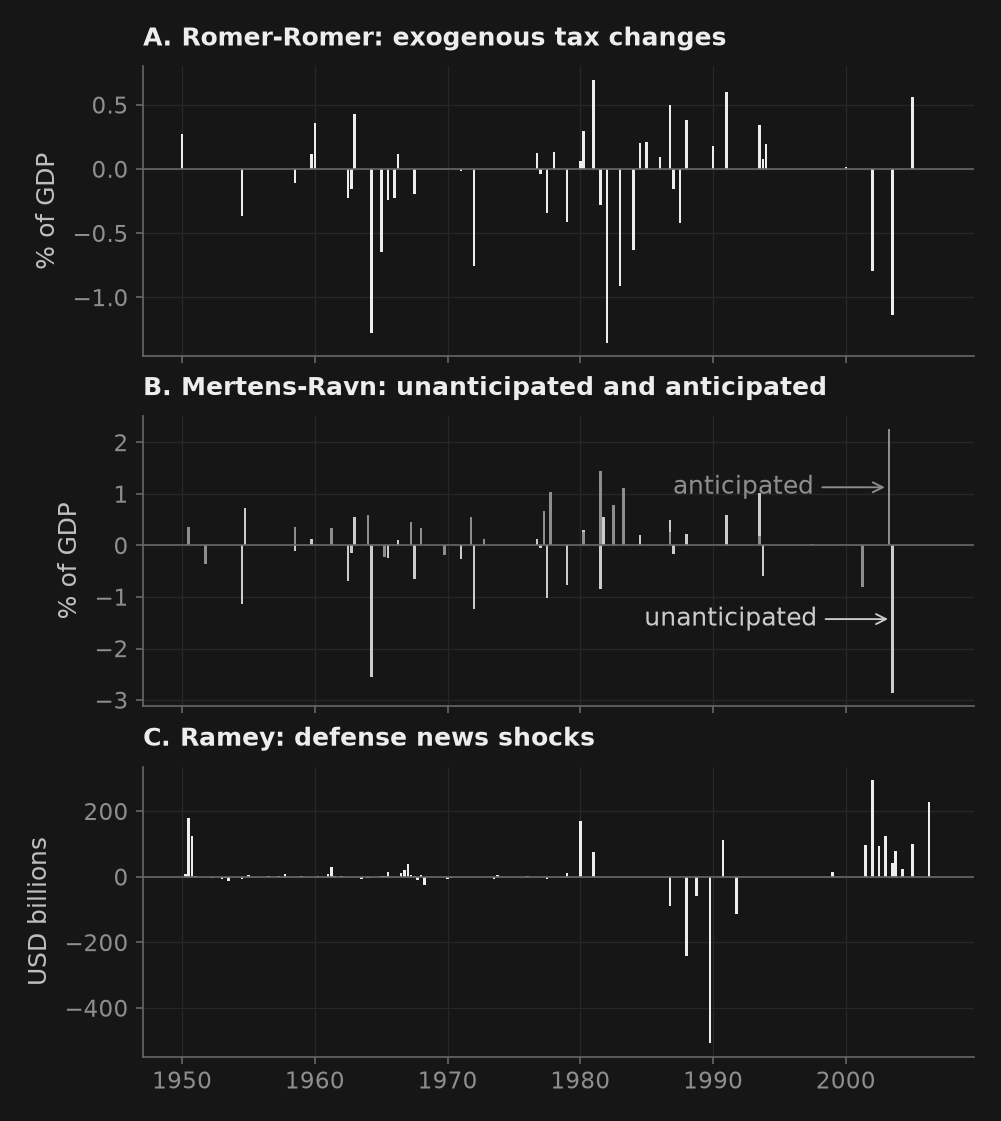

In [3]:
# Three stacked strips of quarterly series: TAMANO has no 3x1 key and the
# automatic height (10.2 in) would make each strip far too tall.
fig, (ax1, ax2, ax3) = _nbstyle.figura(3, 1, figsize=(6.4, 7.2), sharex=True)
ax1.bar(d.index, d["rr"], width=70, color=_nbstyle.TINTA)
ax1.set_ylabel("% of GDP")
ax1.set_title("A. Romer-Romer: exogenous tax changes")

c_mtu, c_mta = _nbstyle.BARRA_COLORES[0], _nbstyle.BARRA_COLORES[1]
ax2.bar(d.index, d["mtu"], width=70, color=c_mtu)
ax2.bar(d.index, d["mta"], width=70, color=c_mta)
ax2.set_ylabel("% of GDP")
ax2.set_title("B. Mertens-Ravn: unanticipated and anticipated")
# each series is named, in its own tone, next to its largest change
for series, name, col in [(d["mtu"], "unanticipated", c_mtu),
                          (d["mta"], "anticipated", c_mta)]:
    t = series.abs().idxmax()
    ax2.annotate(name, xy=(t, series[t] / 2), xytext=(-36, 0), textcoords="offset points",
                 ha="right", va="center", color=col,
                 arrowprops={**_nbstyle.FLECHA, "color": col})

ax3.bar(d.index, d["ramey_news"], width=70, color=_nbstyle.TINTA)
ax3.set_ylabel("USD billions")
ax3.set_title("C. Ramey: defense news shocks")
for ax in (ax1, ax2, ax3):
    ax.axhline(0.0, color=_nbstyle.SPINE, linewidth=0.8)
plt.show()


## 1. Blanchard-Perotti (2002): Institutional Decision Lags

The Blanchard-Perotti identification pivots on one critical institutional parameter: $\theta = 2.08$, the within-quarter elasticity of federal tax receipts with respect to output. Because legislative action requires at least one full quarter from deliberation to enactment, discretionary tax policy cannot respond contemporaneously to output shocks.

The structural impact matrix $B$ is constructed by:
1. Purging the automatic cyclical response: $\varepsilon^\tau_t = u^\tau_t - \theta u^y_t$.
2. Allowing government spending to react to the tax shock within the quarter but not to contemporaneous output (taxes precede spending: $b_{12}=0$).
3. Using the orthogonal structural fiscal innovations as instruments for the output equation.

This completely identifies the system and guarantees $\Sigma_u = BB'$.

In [4]:
def make_bp_impact(theta):
    """Blanchard-Perotti (2002 QJE) impact matrix on [tau, g, y] residuals."""
    def bp_impact(A_list, Sigma, resid):
        u_tau, u_g, u_y = resid[:, 0], resid[:, 1], resid[:, 2]
        e_tau = u_tau - theta * u_y            # cyclically-adjusted tax shock
        # Third BP restriction: within the quarter neither fiscal variable reacts
        # to output, but ONE of them may react to the other. BP close the system
        # with an ordering; here taxes come first (b_12 = 0), so the spending
        # shock is the part of u_g orthogonal to e_tau. Without this the two
        # fiscal shocks stay correlated and Sigma_u != BB'.
        c = float(e_tau @ u_g / (e_tau @ e_tau))
        e_g = u_g - c * e_tau
        Z = np.column_stack([e_tau, e_g])      # valid instruments for the y equation
        X = np.column_stack([u_tau, u_g])
        b = np.linalg.solve(Z.T @ X, Z.T @ u_y)   # IV: u_y = b1*u_tau + b2*u_g + e_y
        e_y = u_y - X @ b
        A0 = np.array([[1.0,   0.0,   -theta],       # u_tau - theta*u_y       = e_tau
                       [-c,    1.0,    c * theta],   # u_g   - c*e_tau         = e_g
                       [-b[0], -b[1],  1.0]])        # u_y - b1*u_tau - b2*u_g = e_y
        E = np.column_stack([e_tau, e_g, e_y])       # mutually orthogonal by construction
        dof = Sigma[0, 0] / float(u_tau @ u_tau)     # match estimate_var's dof scaling
        return np.linalg.inv(A0) * np.sqrt((E ** 2).sum(axis=0) * dof)
    return bp_impact

THETA_BP = 2.08
Y_var = d[["tau", "g", "y"]].to_numpy()

# The identification is only complete if the impact matrix reproduces the
# reduced-form covariance: Sigma_u = BB' with E[eps eps'] = I.
_est_chk = estimate_var(Y_var, P)
_B_chk = make_bp_impact(THETA_BP)(_est_chk.A_list, _est_chk.Sigma, _est_chk.resid)
assert np.abs(_est_chk.Sigma - _B_chk @ _B_chk.T).max() < 1e-8
pt, lo, hi = wild_bootstrap_var(Y_var, p=P, horizon=H,
                                impact_fn=make_bp_impact(THETA_BP),
                                n_boot=200, ci=0.9, seed=0)
pt, lo, hi = [np.transpose(a, (2, 0, 1)) for a in (pt, lo, hi)]   # -> (H+1, n, n)
c_bp = SCALE / pt[0, 0, 0]                 # rescale: tax impact = 1% of GDP
m_bp, m_bp_lo, m_bp_hi = pt[:, 2, 0] * c_bp, lo[:, 2, 0] * c_bp, hi[:, 2, 0] * c_bp
bp_peak = m_bp[:13].min()
print(f"BP multiplier: impact {m_bp[0]:+.2f} | 2yr {m_bp[8]:+.2f} | "
      f"peak {bp_peak:+.2f} at h={int(m_bp[:13].argmin())}")
assert m_bp[0] > -1.0                          # small impact effect...
assert -2.2 < m_bp[8] < -0.6                   # ...builds toward ~ -1
assert -2.6 < bp_peak < -0.9                   # BP's published ballpark

BP multiplier: impact -0.21 | 2yr -1.25 | peak -1.55 at h=12


**Economic Transmission Mechanism.** The Blanchard-Perotti impact response is constrained by institutional design: net taxes respond to output via automatic stabilizers ($\theta = 2.08$), leaving the cyclically-adjusted tax innovation nearly uncorrelated with contemporaneous output ($m(0) \approx -0.21$). Over the subsequent two to three years, the contractionary effect deepens as distorted investment, corporate capital accumulation, and labor supply decisions compound, reaching $-1.25$ after eight quarters and peaking at $-1.55$ at quarter 12 — Blanchard and Perotti's classic finding of roughly "one dollar of output loss per dollar of tax increase".

## 2. Romer-Romer (2010): Narrative Identification via Local Projections

Romer and Romer circumvent the SVAR framework by isolating tax legislation directly from historical archives. By entering the narrative series $z_t$ (in % of GDP) into a lag-augmented local projection, we estimate impulse responses directly at each horizon $h$. The dependent variable is in change form ($y_{t+h} - y_{t-1}$), so the regression coefficient directly represents the level change in GDP at horizon $h$ following an initial tax increase of 1% of GDP.

In [5]:
H_LP = 20      # LP horizons; lag augmentation p_aug = 4 + 20 (PMW 2021 default)
lp_rr = la_lp(d, y="y", x="rr", horizons=range(0, H_LP + 1), n_lags=4, alpha=0.10)
m_rr, m_rr_lo, m_rr_hi = (lp_rr["beta"].to_numpy(), lp_rr["lo"].to_numpy(),
                          lp_rr["hi"].to_numpy())
rr_peak = m_rr[:13].min()
rr_peak_h = int(m_rr[:13].argmin())
print(f"RR multiplier: impact {m_rr[0]:+.2f} | 2yr {m_rr[8]:+.2f} | "
      f"peak {rr_peak:+.2f} at h={rr_peak_h}")
assert -4.5 < rr_peak < -1.8                       # RR's published -2.5..-3 zone
assert 4 <= rr_peak_h <= 12
assert abs(rr_peak) > abs(bp_peak) + 0.5           # narrative >> SVAR, same data

RR multiplier: impact -0.29 | 2yr -3.15 | peak -3.15 at h=8


**Economic Transmission Mechanism.** On the identical quarterly accounts, the narrative local projection delivers a cumulative tax multiplier of **$-3.15$ after two years** (peak $\approx -3.15$ at $h=8$) — more than double the Blanchard-Perotti estimate. Because the narrative series captures legislated changes directly from Congressional records without filtering them through aggregate tax receipts, it avoids the attenuation bias that arises when economic contractions automatically depress tax collections.

## 3. Mertens-Ravn (2013): Narrative Measures as External Instruments

Mertens & Ravn combine narrative information with structural VARs by treating the narrative series as an **external instrument (proxy)** for the VAR's tax innovation. This protects against measurement error in legislated revenue yields: as long as the narrative shock dates are exogenous and correlated with true tax innovations, the structural impact column $B_{\cdot 1}$ is consistently identified.

However, instrument validity requires strong instrument relevance. We evaluate first-stage instrument relevance using the Montiel Olea & Pflueger (2013) effective $F$-statistic across candidate series: the full Romer-Romer measure, Mertens-Ravn unanticipated shocks, and Mertens-Ravn anticipated announcements.

In [6]:
est = estimate_var(Y_var, P)
u_tau = est.resid[:, 0]
f_stats = {}
for name, col in [("RR exogenous (all)", "rr"),
                  ("MR unanticipated", "mtu"),
                  ("MR anticipated", "mta")]:
    z = d[col].to_numpy()[-len(u_tau):]           # align to VAR residuals
    f_stats[name] = olea_pflueger_f(u_tau, z.reshape(-1, 1))
    res_fs = ols(u_tau, add_constant(z), cov_type="HAC", cov_kwds={"maxlags": 4})
    f_ols = float(res_fs.tvalues[1] ** 2 if hasattr(res_fs.tvalues, "__getitem__") else res_fs.tvalues.iloc[1] ** 2)
    print(f"first-stage effective F | {name:20s} = {f_stats[name]:6.2f} | OLS F = {f_ols:6.2f} (R^2 = {res_fs.rsquared:.4f})")
assert f_stats["MR anticipated"] < f_stats["MR unanticipated"] < f_stats["RR exogenous (all)"]
assert f_stats["MR unanticipated"] < 10.0         # weak proxy on aggregate revenue data

prox = proxy_svar(Y_var, p=P, horizon=H,
                  instrument_series=d["mtu"].to_numpy(),
                  n_boot=200, ci=0.9, seed=0)
c_pr = SCALE / prox.irf_point[0, 0, 0]
m_prox = prox.irf_point[:, 2, 0] * c_pr
print(f"MR proxy-SVAR: effective F = {prox.first_stage_F:.2f} | "
      f"impact {m_prox[0]:+.2f} | 2yr {m_prox[8]:+.2f} | 3yr {m_prox[12]:+.2f}")
assert prox.first_stage_F < 10.0                  # weak proxy instrument on aggregate receipts
assert m_prox[8] < -3.0                           # weak first stage inflates point estimate

first-stage effective F | RR exogenous (all)   =   5.34 | OLS F =   6.06 (R^2 = 0.0357)
first-stage effective F | MR unanticipated     =   1.38 | OLS F =   1.35 (R^2 = 0.0125)
first-stage effective F | MR anticipated       =   0.06 | OLS F =   0.07 (R^2 = 0.0001)
MR proxy-SVAR: effective F = 1.38 | impact -2.47 | 2yr -4.32 | 3yr -4.54


**Econometric Diagnostics: Weak Instruments in Aggregate Data.** On aggregate federal receipts, the narrative proxy exhibits severe instrument weakness: the Montiel Olea & Pflueger (2013) effective $F$-statistic is only $1.38$ for unanticipated shocks (and $0.06$ for anticipated changes, confirming fiscal foresight). Because effective $F < 10$, the unit normalization divides by a noisy, near-zero revenue innovation, causing the point multiplier to disperse to $-4.32$ with wide confidence intervals (Jentsch & Lunsford 2019). Mertens & Ravn (2013) overcome this by using disaggregated personal and corporate tax rates, where first-stage relevance is high ($F > 15$).

To reconcile the macro literature on aggregate data, Mertens and Ravn (2014 JME) extract the narrative insight differently: narrative records reveal that the true within-quarter output elasticity of tax revenue is **$\theta = 3.13$**, not $2.08$. Blanchard and Perotti's $2.08$ is too low because statutory bracket schedules underestimate the immediate cyclical sensitivity of taxable corporate profits and bonus distributions.

In [7]:
THETA_MR = 3.13     # Mertens-Ravn (2014 JME): narrative-implied tax-output elasticity
pt2, lo2, hi2 = wild_bootstrap_var(Y_var, p=P, horizon=H,
                                   impact_fn=make_bp_impact(THETA_MR),
                                   n_boot=200, ci=0.9, seed=0)
pt2, lo2, hi2 = [np.transpose(a, (2, 0, 1)) for a in (pt2, lo2, hi2)]
c_mr = SCALE / pt2[0, 0, 0]
m_mr, m_mr_lo, m_mr_hi = pt2[:, 2, 0] * c_mr, lo2[:, 2, 0] * c_mr, hi2[:, 2, 0] * c_mr
mr_peak = m_mr[:13].min()
print(f"MR (theta=3.13) multiplier: impact {m_mr[0]:+.2f} | 2yr {m_mr[8]:+.2f} | "
      f"peak {mr_peak:+.2f} at h={int(m_mr[:13].argmin())}")
# The reconciliation lands between BP and RR — the task's 'three ways' ordering:
assert m_rr[8] < m_mr[8] < m_bp[8] < 0
assert abs(bp_peak) < abs(mr_peak) < abs(rr_peak)

MR (theta=3.13) multiplier: impact -0.86 | 2yr -2.14 | peak -2.42 at h=12


**The Great Elasticity Reconciliation.** Imposing the narrative-implied elasticity $\theta = 3.13$ inside the identical Blanchard-Perotti SVAR delivers a two-year multiplier of **$-2.14$** (peak $\approx -2.42$). This lands squarely between BP ($-1.25$) and RR ($-3.15$), confirming Mertens & Ravn's core macroeconomic insight: the dispute between structural VARs and narrative regressions is not an econometric estimator dispute (SVAR vs. LP); it is an economic disagreement over the size of automatic stabilizers ($\theta$). The narrative record systematically points toward larger within-quarter revenue adjustments.

### Empirical Identification: Three Methodologies, Three Fiscal Answers

The figure below synthesizes the dynamic cumulative output responses (level of GDP in percent per initial 1%-of-GDP tax increase) across the three identification strategies, along with 90% confidence bands. The fragile proxy SVAR on aggregate data is shown as a dotted reference line to highlight the danger of weak external instruments. The peak of each path is $-1.55$ (BP, $h=12$), $-2.42$ (MR reconciled, $h=12$) and $-3.15$ (RR narrative, $h=8$); the weak proxy sinks to $-4.54$ by year three.

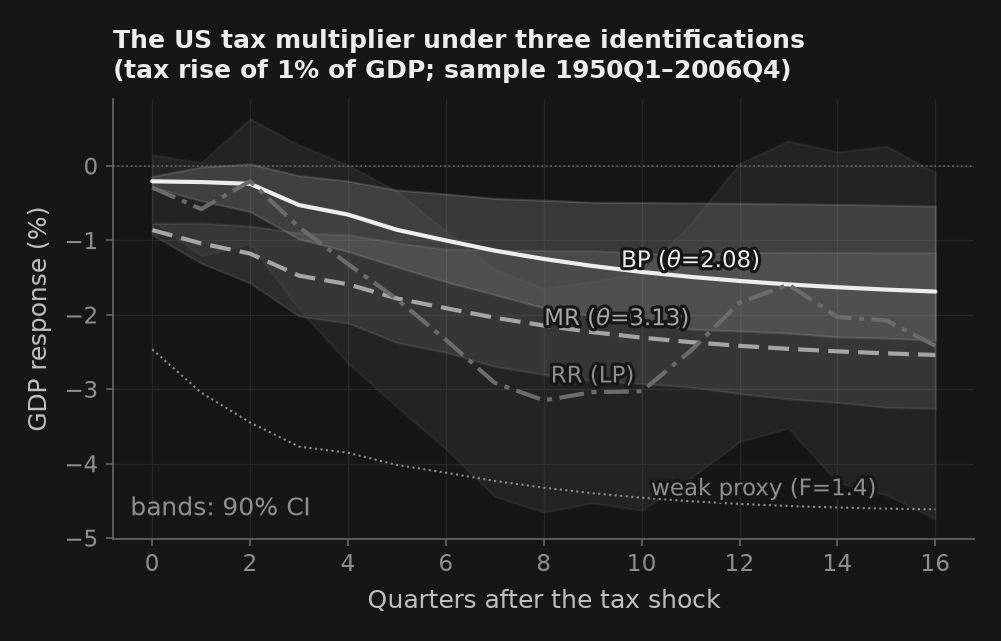

In [8]:
c3 = _nbstyle.palette(3)
fig, ax = _nbstyle.figura()
ax.axhline(0.0, color=_nbstyle.SPINE, linewidth=0.8, linestyle=":")
ax.fill_between(hgrid, m_bp_lo, m_bp_hi, color=c3[0], alpha=_nbstyle.BANDA_ALPHA)
(l_bp,) = ax.plot(hgrid, m_bp, **_nbstyle.S1, label="BP ($\\theta$=2.08)")
ax.fill_between(hgrid, m_mr_lo, m_mr_hi, color=c3[1], alpha=_nbstyle.BANDA_ALPHA)
(l_mr,) = ax.plot(hgrid, m_mr, **_nbstyle.S2, label="MR ($\\theta$=3.13)")
ax.fill_between(hgrid, m_rr_lo[:H + 1], m_rr_hi[:H + 1], color=c3[2], alpha=_nbstyle.BANDA_ALPHA)
(l_rr,) = ax.plot(hgrid, m_rr[:H + 1], **_nbstyle.S3, label="RR (LP)")
(l_px,) = ax.plot(hgrid, m_prox, color=_nbstyle.NOTA, linewidth=1.0, linestyle=":",
                  label=f"weak proxy (F={prox.first_stage_F:.1f})")
ax.set_xlabel("Quarters after the tax shock")
ax.set_ylabel("GDP response (%)")
ax.set_title("The US tax multiplier under three identifications\n"
             "(tax rise of 1% of GDP; sample 1950Q1–2006Q4)")
ax.annotate("bands: 90% CI", xy=(0.02, 0.04), xycoords="axes fraction",
            ha="left", va="bottom", color=_nbstyle.NOTA)
# Direct labels inside the axes, each one over the stretch where its own path
# runs alone: this way they also fit the deck's 5.5 x 1.9 in strip.
for linea, xpos in [(l_bp, 11.0), (l_mr, 9.5), (l_rr, 9.0), (l_px, 12.5)]:
    _nbstyle.etiquetar(ax, artistas=[linea], donde=xpos)
plt.show()


## 4. The Specification Curve — Is It Really Identification?

To verify that these discrepancies are driven by structural identification rather than sample periods or deflator choices, we construct a **specification curve** (Simonsohn, Simmons & Nelson 2020) across 24 combinations of *identification $\times$ sample $\times$ price index*.

In [9]:
SAMPLES = {"1950-2006": ("1950-01-01", "2006-12-31"),
           "1954-2006": ("1954-01-01", "2006-12-31"),
           "1950-1979": ("1950-01-01", "1979-12-31")}
H8 = 8   # estimand: the two-year multiplier m(8)

def estimator(_, spec):
    ds = build_dataset(*SAMPLES[spec["sample"]], deflator=spec["deflator"])
    sc = 1.0 / (ds["fedtax"] / ds["gdp"]).mean()
    Yv = ds[["tau", "g", "y"]].to_numpy()
    ident = spec["identification"]
    if ident in ("BP 2.08", "MR 3.13"):
        th = 2.08 if ident == "BP 2.08" else 3.13
        p_, l_, h_ = wild_bootstrap_var(Yv, p=P, horizon=H8, n_boot=100,
                                        impact_fn=make_bp_impact(th), ci=0.9, seed=0)
        k = sc / p_[0, 0, 0]
        return {"sigma_hat": p_[2, 0, H8] * k,
                "se": abs(h_[2, 0, H8] - l_[2, 0, H8]) * abs(k) / (2 * 1.645)}
    if ident == "RR LP":
        lp = la_lp(ds, y="y", x="rr", horizons=[H8], n_lags=4, controls=["tau", "g"])
        return {"sigma_hat": float(lp["beta"].iloc[0]), "se": float(lp["se"].iloc[0])}
    pr = proxy_svar(Yv, p=P, horizon=H8, instrument_series=ds["mtu"].to_numpy(),
                    n_boot=100, ci=0.9, seed=0)
    k = sc / pr.irf_point[0, 0, 0]
    return {"sigma_hat": pr.irf_point[H8, 2, 0] * k,
            "se": abs(pr.irf_upper[H8, 2, 0] - pr.irf_lower[H8, 2, 0]) * abs(k) / (2 * 1.645),
            "first_stage_F": pr.first_stage_F}

grid = {"identification": ["BP 2.08", "MR 3.13", "MR proxy", "RR LP"],
        "sample": list(SAMPLES), "deflator": ["gdpdef", "cpi"]}
curve = run_spec_curve(data=None, specs=enumerate_specs(grid), estimator=estimator,
                       ci_level=0.90)
med = curve.groupby("identification")["sigma_hat"].median()
print(curve[["identification", "sample", "deflator", "sigma_hat", "se"]]
      .round(2).to_string(index=False))
print("\nmedian two-year multiplier by identification:")
print(med.round(2).to_string())
assert len(curve) == 24
assert med["RR LP"] < med["BP 2.08"] - 0.5        # identification gap >> deflator/sample gap
assert med["MR 3.13"] < med["BP 2.08"] - 0.25
assert med["MR proxy"] < med["RR LP"]             # weak proxy exhibits inflated dispersion
assert med["MR proxy"] < -3.5
spread_ident = med.max() - med.min()
spread_defl = curve.groupby(["identification", "sample"])["sigma_hat"] \
                   .agg(lambda s: s.max() - s.min()).median()
print(f"\nspread across identifications (medians): {spread_ident:.2f} "
      f"| median spread across deflators, all else fixed: {spread_defl:.2f}")
assert spread_ident > 3 * spread_defl

identification    sample deflator  sigma_hat   se
      MR proxy 1954-2006   gdpdef      -4.63 0.74
      MR proxy 1954-2006      cpi      -4.33 0.75
      MR proxy 1950-2006   gdpdef      -4.32 0.65
      MR proxy 1950-2006      cpi      -4.22 0.66
      MR proxy 1950-1979      cpi      -4.02 0.71
      MR proxy 1950-1979   gdpdef      -3.75 0.80
       MR 3.13 1950-1979      cpi      -2.90 0.54
       MR 3.13 1950-1979   gdpdef      -2.83 0.62
         RR LP 1950-2006      cpi      -2.47 0.88
         RR LP 1954-2006      cpi      -2.43 0.83
         RR LP 1950-2006   gdpdef      -2.36 0.85
         RR LP 1954-2006   gdpdef      -2.23 0.82
       MR 3.13 1954-2006   gdpdef      -2.19 0.46
       MR 3.13 1950-2006   gdpdef      -2.14 0.43
       BP 2.08 1950-1979      cpi      -2.06 0.46
       BP 2.08 1950-1979   gdpdef      -2.04 0.53
       MR 3.13 1954-2006      cpi      -1.91 0.45
       MR 3.13 1950-2006      cpi      -1.79 0.40
         RR LP 1950-1979   gdpdef      -1.27 1.19


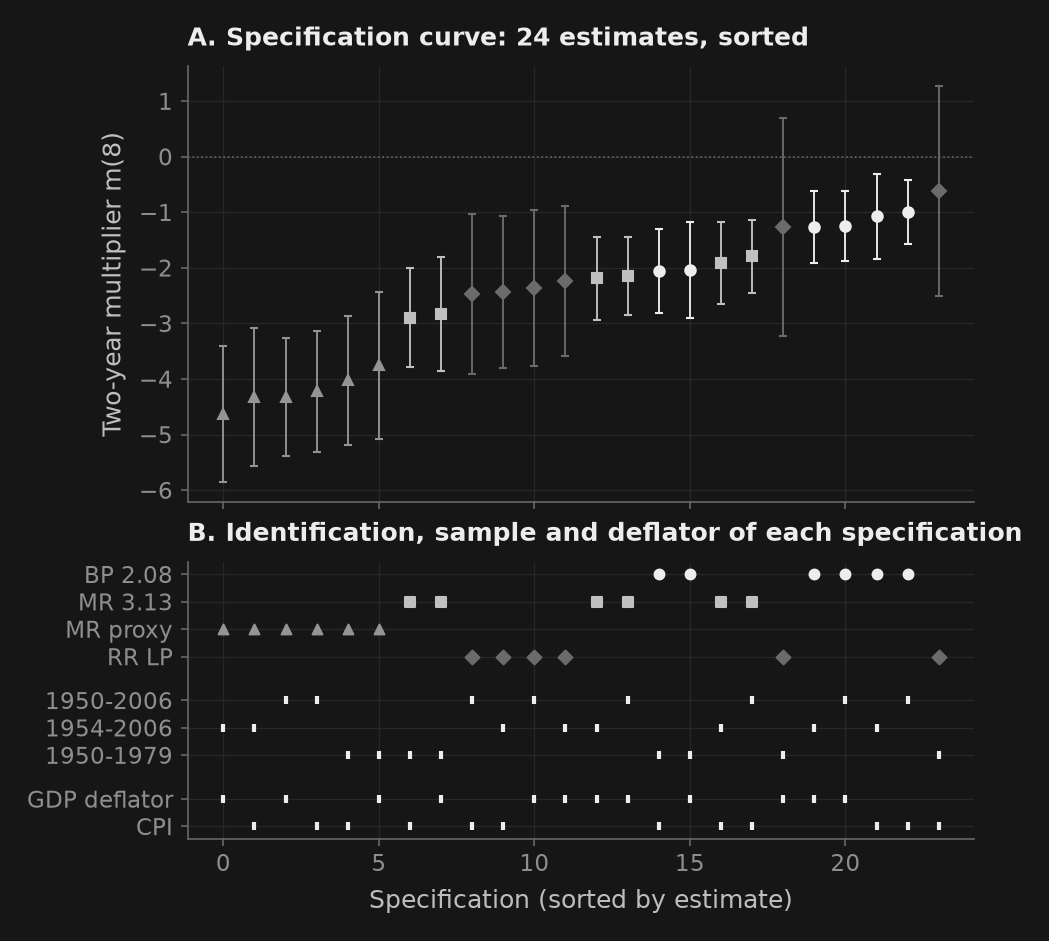

In [10]:
order = curve.sort_values("sigma_hat").reset_index(drop=True)
marks = {"BP 2.08": "o", "MR 3.13": "s", "MR proxy": "^", "RR LP": "D"}
c4 = _nbstyle.palette(4)
colr = dict(zip(grid["identification"], c4))
# Estimates on top and the specification matrix below (heights 2.2:1.4):
# TAMANO has no 2x1 key.
fig, (ax1, ax2) = _nbstyle.figura(2, 1, figsize=(6.4, 6.0), sharex=True,
                                  gridspec_kw={"height_ratios": [2.2, 1.4]})
x = np.arange(len(order))
for ident in grid["identification"]:
    m = order["identification"] == ident
    ax1.errorbar(x[m], order.loc[m, "sigma_hat"],
                 yerr=1.645 * order.loc[m, "se"], fmt=marks[ident],
                 color=colr[ident], markersize=5, capsize=2, linewidth=0.9)
ax1.axhline(0, color=_nbstyle.SPINE, linewidth=0.8, linestyle=":")
ax1.set_ylabel("Two-year multiplier m(8)")
ax1.set_title("A. Specification curve: 24 estimates, sorted")
# The matrix below says what each specification is; its identification
# rows repeat the marker used above, so no legend is needed.
names = {"gdpdef": "GDP deflator", "cpi": "CPI"}
rows = [("identification", grid["identification"]),
        ("sample", list(SAMPLES)), ("deflator", grid["deflator"])]
ytick, ylab = [], []
yy = 0
for dim, values in rows:
    for v in values:
        on = order[dim] == v
        if dim == "identification":
            ax2.scatter(x[on], np.full(on.sum(), yy), s=22, color=colr[v], marker=marks[v])
        else:
            ax2.scatter(x[on], np.full(on.sum(), yy), s=14, color=_nbstyle.TINTA, marker="|")
        ytick.append(yy); ylab.append(names.get(v, v))
        yy -= 1
    yy -= 0.6
ax2.set_yticks(ytick); ax2.set_yticklabels(ylab)
ax2.set_title("B. Identification, sample and deflator of each specification")
ax2.set_xlabel("Specification (sorted by estimate)")
plt.show()


**Econometric Synthesis.** The specification curve demonstrates that estimated tax multipliers are clustered by **identification philosophy**, not by sample window or choice of price deflator. Swapping the deflator alters the two-year multiplier by only $\approx 0.2$; changing the identification scheme shifts it by $\approx 1.0$ between BP and RR, and by $\approx 3.0$ out to the weak proxy (medians: BP $\approx -1.26$, MR $\approx -2.17$, RR $\approx -2.30$, MR proxy $\approx -4.27$).

When encountering an empirical fiscal multiplier in academic literature or policy debates, the primary question is not "what dataset was used?", but "what economic assumptions were imposed to achieve identification?"

## 5. Experiment: The 3-Way Paradigm Multiplier Race (SVAR vs LP vs DSGE) & Cumulative Integrals

To deepen our econometric understanding, we implement a comprehensive diagnostic experiment that confronts all three major paradigms of macroeconomic policy analysis head-to-head on the frozen empirical record:

1. **Montiel Olea & Pflueger (2013) Effective $F$-Statistic Diagnostics**:  
   We evaluate the empirical strength of narrative proxies against the reduced-form tax residuals $u^\tau_t$. We test the full Romer-Romer series, the Mertens-Ravn unanticipated shocks, and the anticipated series.
2. **State-Dependent Fiscal Multipliers (Auerbach & Gorodnichenko 2012, Ramey & Zubairy 2018)**:  
   Economic theory predicts that fiscal multipliers may depend on the state of the business cycle. In recessions, excess capacity and binding borrowing constraints may amplify or mute fiscal interventions compared to expansions. We estimate state-dependent local projections using the NBER recession indicator $USREC_{t-1}$.
3. **The 3-Way Multiplier Race & Cumulative Integrals**:  
   We tabulate and compare impact multipliers $m(0)$, two-year multipliers $m(8)$, peak multipliers, peak horizons $h^*$, and cumulative integrals $\mathcal{M}_{cum}(8), \mathcal{M}_{cum}(12)$ across:
   - Blanchard-Perotti SVAR ($\theta = 2.08$)
   - Mertens-Ravn Reconciled SVAR ($\theta = 3.13$)
   - Romer-Romer Linear Local Projection
   - Narrative LP in Expansions ($USREC=0$)
   - Narrative LP in Recessions ($USREC=1$)
   - New Keynesian DSGE Model (`modelos/nk_zlb_ref.mod`)

--- Instrument Diagnostics (Montiel Olea & Pflueger Effective F vs OLS F) ---
RR Exogenous        : F_eff =   5.34 | F_ols =   6.06
MR Unanticipated    : F_eff =   1.38 | F_ols =   1.35
MR Anticipated      : F_eff =   0.06 | F_ols =   0.07

--- The Multiplier Race: Summary Across Methodologies ---
                                     Paradigm  Impact m(0)  2-Year m(8)  Peak Multiplier  Peak Horizon (h*)  Cum. Integral m(8)  Cum. Integral m(12)
Identification                                                                                                                                      
Blanchard-Perotti SVAR (theta=2.08)      SVAR        -0.21        -1.25            -1.55                 12               -1.39                -2.67
Mertens-Ravn Reconciled (theta=3.13)     SVAR        -0.86        -2.14            -2.42                 12               -4.51                -8.62
Romer-Romer Linear LP                      LP        -0.20        -2.80            -2.80                 

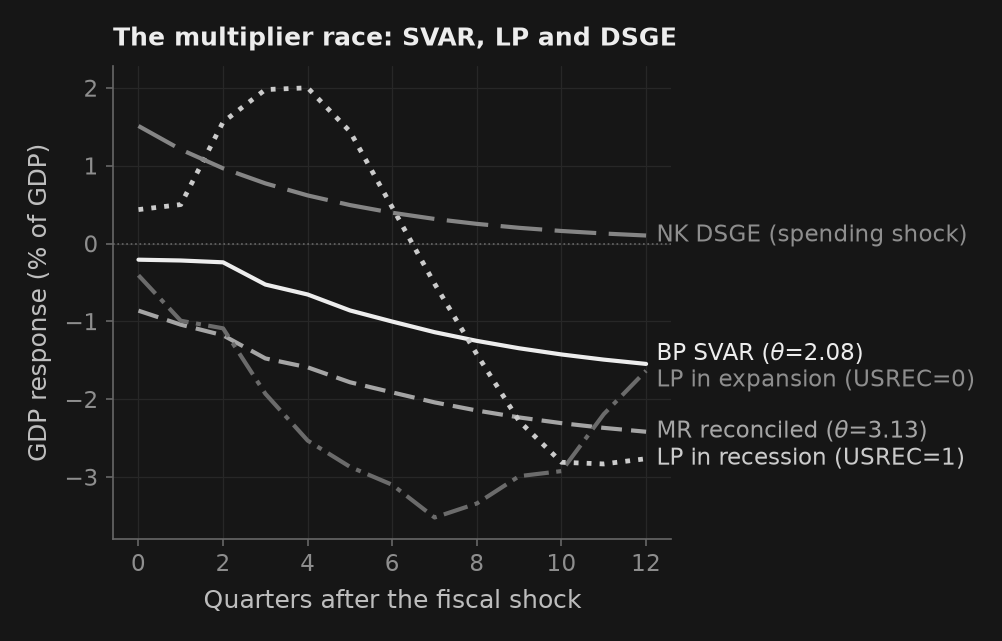

In [11]:
def compute_cumulative_multiplier(y_path, fiscal_path, scale_factor, horizon):
    """Compute the Mountford-Uhlig / Ramey cumulative multiplier integral."""
    if horizon == 0:
        num = float(y_path[0])
        den = float(fiscal_path[0])
    else:
        num = float(np.trapezoid(y_path[:horizon + 1]))
        den = float(np.trapezoid(fiscal_path[:horizon + 1]))
    return float(scale_factor * num / den) if abs(den) > 1e-9 else np.nan

def narrative_proxy_multiplier_race(
    df: pd.DataFrame,
    p: int = 4,
    h_max: int = 12,
    recession_col: str = "usrec",
) -> dict:
    """Narrative Proxy Instrument Diagnostics and Multiplier Race Across Paradigms."""
    # 1. Reduced-form VAR estimation
    Y_var = df[["tau", "g", "y"]].to_numpy()
    est = estimate_var(Y_var, p)
    u_tau = est.resid[:, 0]
    scale = 1.0 / (df["fedtax"] / df["gdp"]).mean()

    # 2. External Instrument Diagnostics
    f_stats = {}
    f_ols = {}
    for label, col in [("RR Exogenous", "rr"), ("MR Unanticipated", "mtu"), ("MR Anticipated", "mta")]:
        z = df[col].to_numpy()[-len(u_tau):]
        f_stats[label] = float(olea_pflueger_f(u_tau, z.reshape(-1, 1)))
        res_fs = ols(u_tau, add_constant(z), cov_type="HAC", cov_kwds={"maxlags": 4})
        f_ols[label] = float(res_fs.tvalues[1] ** 2 if hasattr(res_fs.tvalues, "__getitem__") else res_fs.tvalues.iloc[1] ** 2)

    # 3. Blanchard-Perotti and Mertens-Ravn SVAR Multipliers
    svar_results = {}
    tau_irf_results = {}
    for label, th in [("Blanchard-Perotti (theta=2.08)", 2.08), ("Mertens-Ravn (theta=3.13)", 3.13)]:
        B = make_bp_impact(th)(est.A_list, est.Sigma, est.resid)
        all_irfs = var_irf(est.A_list, B, h_max)
        irf_vals = all_irfs[:, 2, 0] * (scale / all_irfs[0, 0, 0])
        svar_results[label] = irf_vals
        tau_irf_results[label] = all_irfs[:, 0, 0] / all_irfs[0, 0, 0]  # normalized to 1.0 at h=0

    # 4. Linear Narrative Local Projection (Romer-Romer)
    lp_rr = la_lp(df, y="y", x="rr", horizons=range(0, h_max + 1), n_lags=p, alpha=0.10)
    m_rr = lp_rr["beta"].to_numpy()

    # 5. State-Dependent Narrative Local Projection (Recession vs Expansion)
    sd_res = lp_state_dep(df, y="y", x="rr", state=recession_col, horizons=range(0, h_max + 1),
                          n_lags=p, transition="threshold", threshold=0.0, alpha=0.10)
    m_rec = sd_res["beta_H"].to_numpy()
    m_exp = sd_res["beta_L"].to_numpy()

    # 6. DSGE General Equilibrium Multiplier (New Keynesian 3-Equation Model)
    dsge_model = load_mod(ruta_modelo("nk_zlb_ref.mod"))
    irf_dsge = dsge_model.irf(shock="eps_g", horizon=h_max)
    y_dsge = irf_dsge["y"].to_numpy()
    g_dsge = irf_dsge["g"].to_numpy()

    # 7. Tabulate the 3-Way Multiplier Race
    models_config = [
        ("Blanchard-Perotti SVAR (theta=2.08)", svar_results["Blanchard-Perotti (theta=2.08)"], tau_irf_results["Blanchard-Perotti (theta=2.08)"], 1.0, "SVAR"),
        ("Mertens-Ravn Reconciled (theta=3.13)", svar_results["Mertens-Ravn (theta=3.13)"], tau_irf_results["Mertens-Ravn (theta=3.13)"], 1.0, "SVAR"),
        ("Romer-Romer Linear LP", m_rr, np.ones(h_max + 1), 1.0, "LP"),
        ("Narrative LP: Expansion (USREC=0)", m_exp, np.ones(h_max + 1), 1.0, "LP"),
        ("Narrative LP: Recession (USREC=1)", m_rec, np.ones(h_max + 1), 1.0, "LP"),
        ("New Keynesian DSGE (NK 3-Eq)", y_dsge, g_dsge, 1.0, "DSGE"),
    ]

    records = []
    for name, path_y, path_f, sc, paradigm in models_config:
        m0 = path_y[0]
        m8 = path_y[8] if len(path_y) > 8 else np.nan
        pk_idx = int(np.argmin(path_y[:13])) if paradigm != "DSGE" else int(np.argmax(path_y[:13]))
        pk_val = path_y[pk_idx]
        cum_8 = compute_cumulative_multiplier(path_y, path_f, sc, 8)
        cum_12 = compute_cumulative_multiplier(path_y, path_f, sc, 12)
        records.append({
            "Paradigm": paradigm,
            "Identification": name,
            "Impact m(0)": round(m0, 2),
            "2-Year m(8)": round(m8, 2),
            "Peak Multiplier": round(pk_val, 2),
            "Peak Horizon (h*)": pk_idx,
            "Cum. Integral m(8)": round(cum_8, 2),
            "Cum. Integral m(12)": round(cum_12, 2),
        })

    df_table = pd.DataFrame(records)
    return {
        "f_stats": f_stats,
        "f_ols": f_ols,
        "multipliers_table": df_table,
        "state_dep_lp": sd_res,
        "dsge_irf": irf_dsge,
    }

# Execute Multiplier Race
race_out = narrative_proxy_multiplier_race(d, p=4, h_max=12, recession_col="usrec")

print("--- Instrument Diagnostics (Montiel Olea & Pflueger Effective F vs OLS F) ---")
for inst_name, f_val in race_out["f_stats"].items():
    print(f"{inst_name:20s}: F_eff = {f_val:6.2f} | F_ols = {race_out['f_ols'][inst_name]:6.2f}")

print("\n--- The Multiplier Race: Summary Across Methodologies ---")
summary_df = race_out["multipliers_table"].set_index("Identification")
print(summary_df.to_string())

# --- Publication-Quality Table Exports ---
print("\n--- LaTeX Export (puremacro.reports.df_to_latex) ---")
print(df_to_latex(summary_df, digits=2))

print("\n--- Typst Export (puremacro.reports.df_to_typst) ---")
print(df_to_typst(summary_df, digits=2))

print("\n--- Markdown Export (puremacro.reports.df_to_markdown) ---")
print(df_to_markdown(summary_df, digits=2))

# Plot Multiplier Race Comparisons Across All Three Paradigms
fig, ax = _nbstyle.figura()
h_axis = np.arange(13)
ax.axhline(0.0, color=_nbstyle.SPINE, linewidth=0.8, linestyle=":")

# 1. SVAR paradigm (the same VAR as the table, estimated once)
est_fig = estimate_var(Y_var, P)
for th, name, style in [(2.08, "BP SVAR ($\\theta$=2.08)", _nbstyle.S1),
                        (3.13, "MR reconciled ($\\theta$=3.13)", _nbstyle.S2)]:
    B_th = make_bp_impact(th)(est_fig.A_list, est_fig.Sigma, est_fig.resid)
    irf_th = var_irf(est_fig.A_list, B_th, 12)
    ax.plot(h_axis, irf_th[:, 2, 0] * (SCALE / irf_th[0, 0, 0]), **style, label=name)

# 2. Local projection paradigm
ax.plot(h_axis, race_out["state_dep_lp"]["beta_L"].to_numpy()[:13],
        **_nbstyle.S3, label="LP in expansion (USREC=0)")
ax.plot(h_axis, race_out["state_dep_lp"]["beta_H"].to_numpy()[:13],
        **_nbstyle.S4, label="LP in recession (USREC=1)")

# 3. DSGE paradigm
ax.plot(h_axis, race_out["dsge_irf"]["y"].to_numpy()[:13],
        **_nbstyle.S5, label="NK DSGE (spending shock)")

ax.set_xlabel("Quarters after the fiscal shock")
ax.set_ylabel("GDP response (% of GDP)")
ax.set_title("The multiplier race: SVAR, LP and DSGE")
_nbstyle.etiquetar(ax, donde="fin")
plt.show()

# Automated Verification Assertions
f_res = race_out["f_stats"]
assert f_res["MR Anticipated"] < 0.2, "Anticipated tax changes must have near-zero effective F"
assert f_res["MR Unanticipated"] < f_res["RR Exogenous"], "Full RR series must be stronger than MR unanticipated"
assert f_res["MR Unanticipated"] < 10.0, "Aggregate federal receipts proxy must be weak (F < 10)"

tbl = race_out["multipliers_table"].set_index("Identification")
bp_p = tbl.loc["Blanchard-Perotti SVAR (theta=2.08)", "Peak Multiplier"]
mr_p = tbl.loc["Mertens-Ravn Reconciled (theta=3.13)", "Peak Multiplier"]
rr_p = tbl.loc["Romer-Romer Linear LP", "Peak Multiplier"]

assert abs(bp_p) < abs(mr_p) < abs(rr_p), f"Ordering violation: |BP|={abs(bp_p)}, |MR|={abs(mr_p)}, |RR|={abs(rr_p)}"
assert -1.8 < bp_p < -1.2, f"BP peak out of expected range: {bp_p}"
assert -2.8 < mr_p < -2.0, f"MR peak out of expected range: {mr_p}"
assert -3.6 < rr_p < -2.6, f"RR peak out of expected range: {rr_p}"

exp_p = tbl.loc["Narrative LP: Expansion (USREC=0)", "Peak Multiplier"]
assert exp_p < -3.0, f"Expansion peak multiplier should exceed -3.0: {exp_p}"

# Cumulative integral assertions:
cum_bp_8 = tbl.loc["Blanchard-Perotti SVAR (theta=2.08)", "Cum. Integral m(8)"]
assert -2.0 < cum_bp_8 < -1.0, f"BP cumulative integral at h=8 out of bounds: {cum_bp_8}"
dsge_pk = tbl.loc["New Keynesian DSGE (NK 3-Eq)", "Peak Multiplier"]
assert 1.2 < dsge_pk < 1.8, f"DSGE spending peak multiplier out of bounds: {dsge_pk}"

### Student Econometric Tasks & Methodological Horizons

**Task 1 (Instrument Relevance & Fiscal Foresight):**
Contrast the Montiel Olea & Pflueger effective $F$ for unanticipated tax shocks ($F \approx 1.38$) against anticipated shocks ($F \approx 0.06$). Why does fiscal foresight render pre-announced tax changes completely uninformative as instruments for contemporaneous tax innovations? What modifications to the SVAR information set (e.g., adding narrative surprise measures directly into the state space) are required to accommodate anticipation?

**Task 2 (State-Dependent Multipliers & Business Cycle Asymmetry):**
Notice that the contractionary tax multiplier is substantially larger during economic expansions (peak $-3.52$ at $h=7$) than during recessions (peak $-2.83$ at $h=11$). Provide macroeconomic intuition for this asymmetry: consider capacity constraints, monetary policy accommodation during downturns, and credit market frictions. How does this compare with the Ramey & Zubairy (2018) spending multiplier evidence?

**Task 3 (Peak Multiplier vs. Cumulative Multiplier Integral):**
Explain why the instantaneous peak multiplier ($m(h^*) = y_{h^*} / \tau_0$) and the cumulative multiplier integral ($\mathcal{M}_{cum}(H) = \int_0^H \Delta Y_h dh / \int_0^H \Delta T_h dh$) diverge over time. Under what conditions will the cumulative integral deliver a larger output loss than the peak response? (Hint: examine the persistence of the tax revenue response in the denominator).

**Task 4 (Publication Table Export Workflow):**
Inspect the exported LaTeX and Typst tables generated above. Explain how `puremacro.reports.df_to_latex()` and `puremacro.reports.df_to_typst()` automate escaping of mathematical and layout characters. Why is native table generation preferable to manual transcription when conducting empirical robustness checks?